## Реализация архитектуры Transformer своими руками 
---
**Разработчик: Денис Кузнеделев**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mryab/dl-hse-ami/blob/main/week08_transformers/homework.ipynb)

### Introduction
---

В данной МДЗ мы будем реализовывать компоненты архитектуры Трансформер. 

Начиная со статьи [Attention Is All You Need](https://arxiv.org/abs/1706.03762), трансформеры применяются во всевозможных задачах и установили state-of-the-art на множестве бенчмарков. Первоначально они добились успеха в задачах NLP, но затем были успешно применены и в других областях - обработке сигналов, CV и даже RL.

Ниже будет дано описание отдельных модулей и код, который нужно будет написать на основе описания.

### Required imports
---

In [3]:
# Импорт необходимых библиотек для работы с трансформером
import math  # Математические функции (нужны для вычисления позиционного кодирования)
import torch  # Основная библиотека PyTorch для работы с тензорами и нейросетями
import numpy as np  # NumPy для численных вычислений
import torch.nn as nn  # Модуль нейронных сетей PyTorch (содержит слои, функции активации и т.д.)
import torch.nn.functional as F  # Функциональный API PyTorch (содержит функции типа softmax, relu и др.)

# Импорт функций проверки заданий
from check import check_task_1, check_task_2, check_task_3, check_task_4

In [4]:
# Настройка библиотек для визуализации (matplotlib, seaborn)
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

# Установка масштаба шрифтов для графиков
sns.set(font_scale=1.3)

# Установка стиля графиков (темная сетка с серым фоном)
sns.set_style("darkgrid", {"axes.facecolor": ".95"})

# Настройка типа шрифта для корректного экспорта графиков в PDF/PS
matplotlib.rcParams['pdf.fonttype'] = 42  # Type 42 (TrueType) для PDF
matplotlib.rcParams['ps.fonttype'] = 42   # Type 42 (TrueType) для PostScript

# Включение режима отображения графиков прямо в notebook
%matplotlib inline

In [5]:
# Выбор устройства для вычислений
# 'cuda' - использование GPU (графический процессор) для ускорения обучения
# Если GPU недоступен, используйте 'cpu' вместо 'cuda'
# GPU ускоряет вычисления в 10-100 раз для больших моделей
device = torch.device('cuda')

In [116]:
# Фиксация генераторов случайных чисел для воспроизводимости результатов
# Это гарантирует, что при повторном запуске кода вы получите те же самые результаты
# Важно для отладки и сравнения экспериментов
np.random.seed(42)  # Фиксация seed для NumPy
torch.random.manual_seed(42);  # Фиксация seed для PyTorch

### Scaled Dot Product Attention
---

В оригинальной работе [Attention Is All You Need](https://arxiv.org/abs/1706.03762) в качестве механизма внимания 
был использован scaled dot product attention - нормализованное скалярное произведение между key и query. 
На вход подается набор запросов $Q\in\mathbb{R}^{L\times d_k}$, ключей $K\in\mathbb{R}^{L\times d_k}$  и 
значений  $V\in\mathbb{R}^{L\times d_v}$, где $L$ - длина последовательности, а $d_k, d_v$ - размерности query/key и value соотвественно.
Значение attention от элемента $i$ на элемент $j$ зависит от похожести query $q_i$ и key $k_j$. Attention определяется по следующей формуле:

$$ \text{Attention}(Q,K,V)=\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V $$

Произведение матриц $Q K^{T}$ составлено из всех попарных скалярных произведений ключей и значений.


<p align="center">
  <img src="https://github.com/mryab/dl-hse-ami/blob/main/week08_transformers/scaled_dot_product_attn.png?raw=1" width="300"/>
</p>

Дополнительно в операцию может входить бинарная маска $M \in \{0, 1\}$, зануляющая некоторые элементы в матрице attention, если по некоторой причине мы не хотим, чтобы токен $i$ из query взаимодействовал c $j$ из key. Это может быть полезно при генерации последовательностей, когда мы не хотим, чтобы данный токен смотрел вперед, на еще не сгенерированные элементы.


Деление на $\sqrt{d_k}$ необходимо, что выход операции сохранял дисперсию распределения, т.к:
$$
q_i \sim \mathcal{N}(0, 1), k_i \sim \mathcal{N}(0, 1) \to \text{Var}\left(\sum_{i=1}^{d_k} q_i\cdot k_i\right) = d_k
$$

**Задание 1 (0.1 балла):**. Реализуйте операцию scaled dot product.

In [55]:
def scaled_softmax_attention(query, key, value):
    """
    Реализация механизма scaled dot-product attention - основы трансформера.
    
    Это базовый механизм внимания, который определяет, какие элементы последовательности
    важны друг для друга:
    
    Шаг 1: Вычисляем скалярное произведение query @ key^T
           Результат показывает "похожесть" или "совместимость" элементов
    
    Шаг 2: Делим на sqrt(d_k) для стабилизации градиентов
           Без этого значения могут быть слишком большими, и softmax "схлопнется"
    
    Шаг 3: Применяем softmax для получения весов внимания (сумма весов = 1)
           Softmax преобразует числа в вероятностное распределение
    
    Шаг 4: Умножаем веса на value для получения взвешенного выхода
           Так мы "собираем" информацию от важных элементов
    
    Args:
        query: torch.Tensor (..., L, D) - запросы (что ищем)
        key: torch.Tensor (..., L, D) - ключи (с чем сравниваем)
        value: torch.Tensor (..., L, D) - значения (что возвращаем)
    
    Returns:
        res: torch.Tensor (..., L, D) - взвешенная сумма значений
        attention: torch.Tensor (..., L, L) - матрица весов внимания
    
    L - длина последовательности, D - размерность эмбеддинга
    """
    # TODO: Вычислить Q @ K^T, разделить на sqrt(d_k), применить softmax
    # nn.Softmax(dim=1)(query @ key.T / np.sqrt(query.shape[-1]))
    print(query.shape, key.shape, value.shape)
    
    attention = F.softmax(query @ key.transpose(-1, -2) / np.sqrt(query.shape[-1]), dim=-1)
    
    # TODO: Умножить attention на V
    res = attention @ value
    
    return res, attention

In [56]:
query = torch.tensor([[ 0.3367,  0.1288,  0.2345,  0.2303],
                      [-1.1229, -0.1863,  2.2082, -0.6380],
                      [ 0.4617,  0.2674,  0.5349,  0.8094]])
key   = torch.tensor([[ 1.1103, -1.6898, -0.9890,  0.9580],
                      [ 1.3221,  0.8172, -0.7658, -0.7506],
                      [ 1.3525,  0.6863, -0.3278,  0.7950]])
value = torch.tensor([[ 0.2815,  0.0562,  0.5227, -0.2384],
                      [-0.0499,  0.5263, -0.0085,  0.7291],
                      [ 0.1331,  0.8640, -1.0157, -0.8887]])

In [57]:
res, attn = scaled_softmax_attention(query, key, value)

torch.Size([3, 4]) torch.Size([3, 4]) torch.Size([3, 4])


**Sanity check**. 

Матрица attn должна быть размера $(L, L)$ и столбцы должны суммироваться в 1.

In [58]:
attn.shape

torch.Size([3, 3])

In [59]:
attn.sum(dim=1)

tensor([1.0000, 1.0000, 1.0000])

In [60]:
check_task_1(res, attn)

 Well done :)


### Multihead Attention Layer
---

Scaled dot product attention задает правило, по которому элементы последовательности взаимодейтсвуют друг с другом. Но может быть полезно задавать несколько различных правил взаимодействия. Поэтому последовательности $Q, K, V$ разбиваются на $h$
частей вдоль размерности эмбединнга, и для каждой из них независимо считаем attention, а затем конкатенируем результат. К сконкатенированному результату применяется линейное преобразование $W_O$:

$$
\begin{split}\begin{split}
    \text{Multihead}(Q,K,V) & = \text{Concat}(\text{head}_1,...,\text{head}_h)W^{O}\\
    \text{where } \text{head}_i & = \text{Attention}(QW_i^Q,KW_i^K, VW_i^V)
\end{split}\end{split}
$$

Обучаемыми параметрами являются матрицы проекции $W_Q, W_K, W_V$ и $W_O$.
Ниже приведен граф вычислений:
<p align="center">
  <img src="https://github.com/mryab/dl-hse-ami/blob/main/week08_transformers/multihead_attention.png?raw=1" width="300"/>
</p>

**Задание 2 (0.1 балла):**. Реализуйте класс  `MultiheadAttention`, реализующий операции, описанные выше.

<span style="color:red">Замечание</span>.

Обратите внимание, что слои `q_proj`, `k_proj`, `v_proj` создают последовательность для всех голов одноновременно, то есть их выходная размерность должна быть $\mathbb{R}^{d_{embed}}$, а не $\mathbb{R}^{d_{embed} / h}$. 

In [61]:
from util import hardcode_parameters

In [62]:
list() <-> list.__init__()
nn.Softmax() <-> nn.Softmax.__init__()

SyntaxError: invalid syntax (1753632585.py, line 1)

In [63]:
class MultiheadAttention(nn.Module):
    """
    Механизм многоголового внимания (Multi-Head Attention).
    
    Почему несколько голов?
    ----------------------
    Одна голова attention может найти только один тип зависимостей.
    Несколько голов позволяют модели одновременно:
    - Голова 1: искать синтаксические связи (подлежащее-сказуемое)
    - Голова 2: искать семантические связи (синонимы, антонимы)
    - Голова 3: искать позиционные зависимости (соседние слова)
    - и так далее...
    
    Алгоритм работы:
    ----------------
    1. Проецируем Q, K, V через линейные слои в num_heads подпространств
       Каждое подпространство имеет размерность embed_dim / num_heads
    
    2. Применяем scaled dot-product attention к каждой голове НЕЗАВИСИМО
       Каждая голова учится своим паттернам
    
    3. Конкатенируем результаты всех голов вместе
       Так мы объединяем найденную разными головами информацию
    
    4. Применяем финальную линейную проекцию
       Преобразуем конкатенированный вектор обратно в embed_dim
    
    Параметры:
        embed_dim: полная размерность эмбеддинга (например, 512)
        num_heads: количество голов внимания (например, 8)
        
    Важно: embed_dim должна делиться на num_heads!
    """
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        # Проверка: размерность должна делиться на количество голов
        assert embed_dim % num_heads == 0, "embed_dim должна делиться на num_heads"
        
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads  # размерность каждой головы
        
        # TODO: Создать линейные слои для проекции Q, K, V
        # Каждый слой преобразует embed_dim -> embed_dim
        # Затем мы разделим результат на num_heads частей
        # переводим из входной размерности эмбеддинга 512 в 8 векторов по 64
        self.q_proj = nn.Linear(self.embed_dim, self.head_dim * self.num_heads)
        self.k_proj = nn.Linear(self.embed_dim, self.embed_dim)
        self.v_proj = nn.Linear(self.embed_dim, self.embed_dim)
        
        # TODO: Финальная проекция после конкатенации голов
        # собираем 8 контекстов слова размера 64 и переводим в изначальную размерность 512
        self.out_proj = nn.Linear(self.head_dim * self.num_heads, self.embed_dim)
    
    def forward(self, x, return_attention=False):
        """
        Args:
            x: torch.Tensor (batch_size, length_of_sequence, embed_dim)
            return_attention: If specified, returns attention along with outputs
        Returns:
            outputs: torch.Tensor (batch_size, length_of_sequence, embed_dim)
            attention: Optional[torch.Tensor] (batch_size, num_heads, length_of_sequence, length_of_sequence)

        B is batch size, L is the length of sequence, D is the embedding dimension
        """
        # проекция queries по каждой из последовательности батча
        # для каждой из последовательности посчитали матрично сразу все Q_i, где i - индекс головы head
        Queries = self.q_proj(x) # self.q_proj.forward(x) 
        Keys = self.k_proj(x)
        Values = self.v_proj(x)

        # размерность Queries: batch_size, length_of_sequence, embed_dim (512)
        # в одну голову пойдет: batch_size, length_of_sequence, embed_dim / num_heads (64)
        '''
        for head_i in range(self.num_heads):
            # считаем query для 0-ой головы: query[:, :, 0-64]
            # считаем query для 1-ой головы: query[:, :, 64-128]
            Queries[:, :, head_i * self.head_dim : (head_i + 1) * self.head_dim]
        '''

        # размерность query у меня: num_heads, batch_size, length_of_sequence, head_dim
        query = torch.stack(
            [
                Queries[..., head_i * self.head_dim : (head_i + 1) * self.head_dim] 
                     for head_i in range(self.num_heads)
            ]
        )

        key = torch.stack(
            [
                Keys[..., head_i * self.head_dim : (head_i + 1) * self.head_dim] 
                     for head_i in range(self.num_heads)
            ]
        )

        value = torch.stack(
            [
                Values[..., head_i * self.head_dim : (head_i + 1) * self.head_dim] 
                     for head_i in range(self.num_heads)
            ]
        )

        results, attentions = [], []
        for head_i in range(self.num_heads):
            res_i, attn_i = scaled_softmax_attention(query[head_i], key[head_i], value[head_i])
            results.append(res_i)
            attentions.append(attn_i)
        
        outputs = self.out_proj(torch.concatenate(results, dim=-1))
        if return_attention is False:
            return outputs
        return outputs, attentions
        


In [64]:
multihead_attention = MultiheadAttention(4, 2)

In [65]:
hardcode_parameters(multihead_attention)

In [66]:
inputs  = torch.stack([torch.cos(i * torch.ones(4)) for i in range(3)])[None, ...]

with torch.no_grad():
    outputs = multihead_attention(inputs)

torch.Size([1, 3, 2]) torch.Size([1, 3, 2]) torch.Size([1, 3, 2])
torch.Size([1, 3, 2]) torch.Size([1, 3, 2]) torch.Size([1, 3, 2])


In [67]:
check_task_2(outputs)

 Well done :)


### Encoder Block
---

Архитектура трансформера в оригинальной статье состоит из последовательности блоков энкодера и декодера. 

<p align="center">
  <img src="https://github.com/mryab/dl-hse-ami/blob/main/week08_transformers/transformer_architecture.png?raw=1" width="300" />
</p>

В данной МДЗ необходимо будет реализовать только энкодер. 

Блок энкодера состоит из операции `MultiheadAttention` и применения `FeedForward` сети к каждому токену по отдельности. 

К выходу `MultiheadAttention` и `FeedForward`
прибавляется skip connection, и к полученной сумме применяется `LayerNormalization`.

В качестве `FeedForward` сети берется простая двуслойная сеть с некоторой активацией (обычно  `ReLU` или `GELU`).

Таким образом, энкодер выполняет следующее:
$$
x = \text{LayerNorm}(x+\text{MultiheadAttention}(x,x,x)) 
$$
$$
\begin{split}\begin{split}
    \text{FFN}(x) & = \mathrm{Act}(x W_1 + b_1) W_2 + b_2\\
    x & = \text{LayerNorm}(x + \text{FFN}(x))
\end{split}\end{split}
$$

В целях регуляризации на выход `MultiheadAttention` и `FeedForward`, но перед `LayerNorm` можно накинуть `Dropout`.

**Задание 3 (0.1 балла):**. Реализуйте класс  `EncoderBlock`, реализующий операции, описанные выше.

In [68]:
class EncoderBlock(nn.Module):
    """
    Один блок энкодера трансформера.
    
    Архитектура блока:
    ==================
    
    Input (B, L, embed_dim)
           |
           ├─────────────────────────────────────┐
           |                                     |
           ├→ Multi-Head Attention               | (residual connection)
           |                                     |
           └→ Dropout → Add ─────────────────────┘
                         |
                         ├→ LayerNorm
                         |
                         ├─────────────────────────────┐
                         |                             |
                         ├→ Feed-Forward Network       | (residual connection)
                         |    (Linear → Activation     |
                         |     → Linear)                |
                         |                             |
                         └→ Dropout → Add ─────────────┘
                                      |
                                      ├→ LayerNorm
                                      |
                                   Output (B, L, embed_dim)
    
    Ключевые идеи:
    ==============
    
    1. Multi-Head Attention:
       Позволяет каждому токену "общаться" с другими токенами
       и собирать от них релевантную информацию
    
    2. Feed-Forward Network (FFN):
       Обрабатывает каждый токен независимо (но с общими весами)
       Добавляет нелинейность и выразительность модели
       Обычно: embed_dim -> feedforward_dim (расширение) -> embed_dim (сжатие)
    
    3. Residual Connections (Add):
       Суммируем вход и выход каждого sub-layer: output = input + sublayer(input)
       Это помогает градиентам течь через глубокую сеть
       Решает проблему затухающих градиентов
    
    4. Layer Normalization:
       Нормализует активации для стабильности обучения
       Применяется ПОСЛЕ residual connection (Post-LN)
    
    5. Dropout:
       Регуляризация - случайно "выключает" нейроны во время обучения
       Предотвращает переобучение
    """

    def __init__(self, embed_dim, num_heads, feedforward_dim, activation=nn.ReLU, dropout=0.0):
        """
        Инициализация энкодерного блока.
        
        Args:
            embed_dim - размерность входа/выхода (Dimensionality of the input)
            num_heads - количество голов в multi-head attention
            feedforward_dim - размерность скрытого слоя в FFN (обычно 4 * embed_dim)
            activation - функция активации в FFN (ReLU, GELU и т.д.)
            dropout - вероятность dropout для регуляризации
        """
        super().__init__()
        
        # Multi-Head Attention слой
        # Позволяет токенам взаимодействовать и обмениваться информацией
        self.attention = MultiheadAttention(embed_dim, num_heads)
        
        # Feed-Forward Network (две линейные проекции с активацией между ними)
        # Архитектура: embed_dim -> feedforward_dim -> embed_dim
        # Увеличиваем размерность (для большей выразительности), затем сжимаем обратно
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, feedforward_dim),
            activation(),
            nn.Linear(feedforward_dim, embed_dim)
        )
        
        # Layer Normalization слои
        # Нормализуют активации по размерности эмбеддинга
        # norm1 - после attention, norm2 - после ffn
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        
        # Dropout слои для регуляризации
        # Применяются после attention и после ffn
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, return_attention=False):
        """
        Прямой проход через энкодерный блок.
        
        Args:
            x: torch.Tensor (B, L, D)
               B - размер батча
               L - длина последовательности
               D - размерность эмбеддинга (embed_dim)
            return_attention: bool - возвращать ли карту внимания
        
        Returns:
            outputs: torch.Tensor (B, L, D) - выход блока
            attention: Optional[torch.Tensor] (B, num_heads, L, L) - карта внимания (если запрошено)
        """
        # SUB-LAYER 1: Multi-Head Attention
        # ===================================
        
        if return_attention is True:
            # Вызываем attention с возвратом карты внимания
            out, attention = self.attention(x, return_attention=True)
        else:
            # Вызываем attention без возврата карты внимания
            out = self.attention(x, return_attention=False)
        
        # Применяем dropout к выходу attention (для регуляризации)
        out = self.dropout(out)
        
        # Residual connection: складываем вход и выход attention
        # Это позволяет градиентам течь напрямую через блок
        out = x + out
        
        # Layer Normalization после residual connection
        # Нормализуем активации для стабильности обучения
        out = self.norm1(out)
        
        # SUB-LAYER 2: Feed-Forward Network
        # ==================================
        
        # Применяем FFN к каждому токену независимо
        # FFN состоит из двух линейных слоёв с активацией между ними
        new_out = self.ffn(out)
        
        # Применяем dropout к выходу FFN
        new_out = self.dropout(new_out)
        
        # Residual connection: складываем вход и выход FFN
        new_out = new_out + out
        
        # Layer Normalization после residual connection
        outputs = self.norm2(new_out)
        
        # Возвращаем выход и (опционально) карту внимания
        if return_attention:
            return outputs, attention
        else:
            return outputs


### Positional Encoding
---

Описанная выше конструкция очень гибкая и универсальная в плане возможности преобразования последовательностей. 
Но есть один нюанс: абсолютное положение токенов никак не определено в текущей форме, и операция `EncoderBlock`
обладает перестановочной симметрией. То есть, если переставить токены в последовательности, то выход от переставленной последовательности будет таким же, как если прогнать исходную последовательность, а затем ее переставить.

Сгенерируем рандомную последовательность.

In [130]:
encoder_block = EncoderBlock(embed_dim=24, num_heads=3, feedforward_dim=24 * 4, dropout=0.0)

In [131]:
inputs = torch.randn(1, 16, 24)

Выход от исходной последовательности

In [132]:
outputs = encoder_block(inputs)

Сгенерируем случайную перестановку

In [133]:
ids_perm = torch.randperm(inputs.size(1))
shuffled_inputs = inputs[:, ids_perm, :]

Посчитаем выход для переставленной последовательности

In [134]:
shuffled_outputs = encoder_block(shuffled_inputs)

И сравним переставленный выход исходной последовательности с выходом переставленной

In [135]:
torch.allclose(outputs[:, ids_perm, :], shuffled_outputs, atol=1e-4, rtol=1e-4)

True

Вуаля! Совпадают.

Но во многих задачах важен порядок, и чтобы его каким-то образом учесть добавляют так называемый PositionalEncoding, который явно задает информацию о положении токена в последовательности. Он может быть как обучаемым, так и зафиксированным.
В оригинальной работе Attention is all you need был выбран следующий энкодинг и синусов и косинусов разных частот:

$$
\begin{split}PE_{(pos,i)} = \begin{cases}
    \sin\left(\frac{pos}{10000^{i/d_{\text{model}}}}\right) & \text{if}\hspace{3mm} i \text{ mod } 2=0\\
    \cos\left(\frac{pos}{10000^{(i-1)/d_{\text{model}}}}\right) & \text{otherwise}\\
\end{cases}\end{split}
$$

$PE_{(pos,i)}$ обозначает позиционный энкодинг токена в позиции $pos$, а $i$ нумерует размерность эмбеддинга.

**Задание 4 (0.1 балла):**. Реализуйте класс  `PositionalEmbedding`, добавляющий позиционный энкодинг определенный выше к входной последовательности.

In [136]:
class PositionalEncoding(nn.Module):
    """
    Позиционное кодирование для трансформера.
    
    Проблема:
    =========
    Механизм attention сам по себе не учитывает порядок токенов!
    Для него последовательности "кот ест рыбу" и "рыбу ест кот" неразличимы.
    
    Решение:
    ========
    Добавляем к эмбеддингам специальные векторы, которые кодируют позицию.
    Используем синусоиды разных частот:
    
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    
    Где:
    - pos - позиция токена (0, 1, 2, ...)
    - i - индекс размерности (0, 1, 2, ..., d_model-1)
    - d_model - размерность эмбеддинга
    
    Преимущества синусоид:
    ----------------------
    1. Ограниченные значения [-1, 1]
    2. Модель может работать с длинами больше, чем видела при обучении
    3. Линейная связь между позициями
    4. Разные частоты -> богатое представление позиций
    """

    def __init__(self, embed_dim, max_len: int = 5000):
        """
        Инициализация позиционного кодирования.
        
        Args:
            embed_dim - размерность эмбеддинга (Hidden dimensionality)
            max_len - максимальная длина последовательности, которую можем обработать
        """
        super().__init__()
        
        # Создаём матрицу позиционных кодирований размера (1, max_len, embed_dim)
        # 1 в начале - для broadcasting по batch dimension
        
        # Создаём вектор позиций: [0, 1, 2, ..., max_len-1]
        # unsqueeze(1) превращает его в столбец: (max_len, 1)
        
        # Вычисляем делители для разных размерностей
        # Это создаёт геометрическую прогрессию частот
        # div_term = [1, 1/k, 1/k^2, ..., 1/k^(embed_dim/2)]
        # где k = 10000^(2/embed_dim)
        div_term = 
        
        # Применяем sin к чётным индексам (0, 2, 4, ...)
        # position * div_term создаёт матрицу (max_len, embed_dim/2)
        # где каждый столбец имеет свою частоту колебаний
        
        
        # Применяем cos к нечётным индексам (1, 3, 5, ...)
        # Используем те же частоты, но со сдвигом фазы (cos вместо sin)
        
        # Регистрируем pe как buffer (не обучаемый параметр, но часть состояния модели)
        # persistent=False означает, что не будем сохранять в state_dict
        # (можно пересчитать при загрузке)
        self.register_buffer('pe', pe, persistent=False)

    def forward(self, x):
        """
        Добавление позиционного кодирования к эмбеддингам.
        
        Args:
            x: torch.Tensor (B, L, embed_dim) - эмбеддинги токенов
               B - размер батча
               L - длина последовательности
               embed_dim - размерность эмбеддинга
        
        Returns:
            out: torch.Tensor (B, L, embed_dim) - эмбеддинги + позиционное кодирование
        """
        # Добавляем позиционное кодирование к входным эмбеддингам
        # Broadcasting автоматически расширит pe для всех примеров в батче
        # Результат: каждый токен получает информацию о своей позиции в последовательности
        out =
        return out

Визуализируем энкодинг

In [137]:
positional_encoding = PositionalEncoding(embed_dim=64, max_len=128)
pe = positional_encoding.pe[0]

In [138]:
check_task_3(pe)

 Well done :)


In [139]:
pe = positional_encoding.pe.numpy()[0]

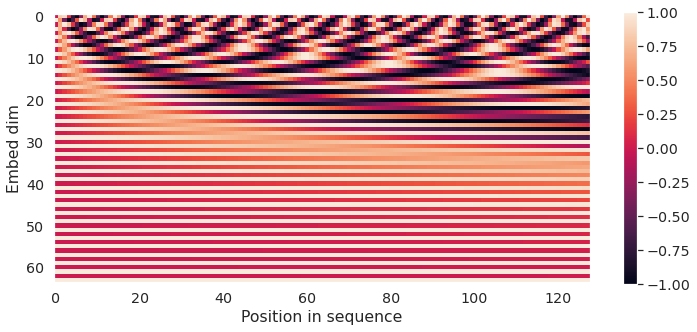

In [140]:
fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(pe.T)
ax.grid(False)

ax.set_ylabel(r'Embed dim')
ax.set_xlabel(r'Position in sequence')

fig.colorbar(im, ax=ax);

Implementation check

In [141]:
check_task_4(positional_encoding)

 Well done :)


### Transformer 
---

Теперь у нас есть все необходимые компоненты, чтобы собрать трансформер своими руками.
Сам по себе трансформер может выполнять великое множество задач, но в рамках данной МДЗ мы ограничимся задачей классификации последовательностей.

Архитектура состоит из следующих компонент:
- Линейное преобразование входной последовательности : $\mathbb{R}^{d_{in}} \rightarrow \mathbb{R}^{d_{embed}}$, примененное поэлементно к каждому токену
- Один или несколько блоков `EncoderBlock`
- `PositionalEmbedding` 
- Для задачи классификации создается специальный токен `[CLS]`, который прибавляется в начало (или конец последовательности)
- `[CLS]` токен, пропущенный через последовательность, подается на вход классификатора (скажем, линейного слоя $\mathbb{R}^{d_{embed}} \rightarrow \mathbb{R}^{|C|}$, $|C|$ - число классов).

**Задание 5 (0.2 балла):** Реализуйте класс  `TransformerForSequenceClassification`, принимающий на вход последовательность и предсказывающий ее класс.

In [305]:
class TransformerForSequenceClassification(nn.Module):
    """
    Полная архитектура трансформера для классификации последовательностей.
    
    Компоненты (слои) трансформера:
    ================================
    
    1. input_embedding: nn.Embedding
       Преобразует дискретные токены (числа 0, 1, 2, ...) в векторные представления
       Например: токен 42 -> вектор [0.1, -0.3, 0.5, ..., 0.2] размерности embed_dim
    
    2. positional_encoding: PositionalEncoding
       Добавляет информацию о позиции токена в последовательности
       Без этого трансформер не различает порядок слов!
       "кот ест рыбу" и "рыбу ест кот" будут выглядеть одинаково
    
    3. cls_token: nn.Parameter  
       Специальный обучаемый токен [CLS] для агрегации информации
       Добавляется в начало/конец последовательности
       После прохождения через encoder содержит информацию о всей последовательности
    
    4. encoder: nn.Sequential из EncoderBlock'ов
       Стек из num_layers энкодерных блоков
       Каждый блок = Multi-Head Attention + Feed-Forward сеть + LayerNorm + residual connections
       Каждый следующий слой строит более абстрактные представления
    
    5. classifier: nn.Linear
       Финальный линейный слой для классификации
       Берет [CLS] токен и преобразует его в вероятности классов
    
    Поток данных:
    =============
    tokens -> embedding -> +positional encoding -> +[CLS] -> encoder blocks -> [CLS] -> classifier -> logits
    
    Пример:
    -------
    Вход: ["привет", "мир"] -> [5, 12] (индексы токенов)
    После embedding: [[0.1, 0.2, ...], [0.3, -0.1, ...]]
    После positional encoding: добавляется информация о позициях
    Добавляем [CLS]: [[CLS_vector], [0.1, 0.2, ...], [0.3, -0.1, ...]]
    После encoder: [[enriched_CLS], [enriched_tok1], [enriched_tok2]]
    Берем [CLS]: [enriched_CLS]
    Классификатор: [enriched_CLS] -> [0.8, 0.1, 0.1] (вероятности 3 классов)
    """
    def __init__(self, input_dim, embed_dim, num_classes, num_heads, 
                 feedforward_dim, num_layers, activation=nn.GELU, 
                 max_len=5000, dropout=0.0):
        super().__init__()
        
        # Инициализация компонентов модели
        
        # TODO: CLS токен - обучаемый вектор размерности (embed_dim,)
        # Инициализируем из стандартного нормального распределения N(0, 1)
        # nn.Parameter делает тензор обучаемым параметром модели
        self.cls_token = # TODO
        
        # TODO: Слой эмбеддинга - преобразует индексы токенов в векторы
        self.input_embedding = # TODO
        
        # TODO: Позиционное кодирование - добавляет информацию о порядке токенов
        self.positional_encoding = # TODO
        
        # TODO: Создать список из num_layers энкодерных блоков
        encoder_blocks = # TODO
        
        # Объединяем блоки в последовательность (Sequential применяет их по очереди)


        self.classifier = # TODO

   def forward_attention(self, x):
        """
        Метод для извлечения карт внимания из всех энкодерных блоков.
        Используется для визуализации и анализа того, на что "смотрит" модель.
        
        Карты внимания показывают:
        - Какие токены взаимодействуют друг с другом
        - Какие паттерны нашла модель
        - Как информация течёт через слои
        
        Args:
            x: torch.Tensor (B, L, |V|)
               B - размер батча (количество примеров)
               L - длина последовательности
               |V| - размер словаря
               
        Returns:
            attn: List[torch.Tensor] - список из num_layers матриц внимания
                  Каждая матрица имеет размер (B, num_heads, L+1, L+1)
                  L+1 потому что добавляется [CLS] токен
        """
        attention = []  # Список для накопления карт внимания с каждого слоя
        
        # Применяем эмбеддинг и позиционное кодирование
        # Преобразуем индексы в векторы и добавляем информацию о позициях
        x = 
        
        # Подготавливаем [CLS] токены для всего батча
        # unsqueeze(0) добавляет batch dimension: (embed_dim,) -> (1, embed_dim)
        # repeat размножает на весь батч: (1, embed_dim) -> (B, 1, embed_dim)
        cls_tokens = self.cls_token.unsqueeze(0).repeat(x.shape[0], 1, 1)
        
        # Конкатенируем [CLS] с последовательностью
        # x: (B, L, embed_dim) + cls_tokens: (B, 1, embed_dim) = (B, L+1, embed_dim)
        input =
        
        # Проходим через каждый энкодерный блок
        # Вызываем блок с флагом return_attention=True
        # Блок вернёт обновлённую последовательность И карту внимания
        # Сохраняем карту внимания этого слоя
            
        return attention

    def forward(self, x):
        """
        Прямой проход (forward pass) для классификации.
        Преобразует входную последовательность токенов в логиты классов.
        
        Args:
            x: torch.Tensor (B, L, |V|) или (B, L)
               B - размер батча
               L - длина последовательности
               |V| - размер словаря (если one-hot) или просто индексы
               
        Returns:
            output: torch.Tensor (B, |C|)
                    B - размер батча
                    |C| - количество классов
                    Возвращаемые значения - это логиты (перед softmax)
        """
        # Применяем эмбеддинг и позиционное кодирование
        # Шаг 1: индексы -> векторы
        # Шаг 2: добавляем информацию о позициях
        x = 
        
        # Подготовка [CLS] токенов для батча (аналогично forward_attention)
        cls_tokens =
        
        # Конкатенируем последовательность с [CLS] токеном
        # [CLS] будет агрегировать информацию о всей последовательности
        input = 
        
        # Пропускаем через все энкодерные блоки
        # Каждый блок обогащает представления через attention и feedforward
        encoded = 
        
        # Извлекаем [CLS] токен (находится на последней позиции, индекс -1)
        # encoded: (B, L+1, embed_dim) -> cls_output: (B, embed_dim)
        cls_output =
        
        # Применяем классификатор к [CLS] токену
        # (B, embed_dim) -> (B, num_classes)
        output = 
        
        return output

### Data
---
В данной МДЗ в качестве задачи, которой мы будем обучать трансформер, является определение того, является ли строка палиндромом. То есть тождественна ли строка, написанная задом наперед, исходной строке.

$$
a b f g a a g f b a \quad \mathrm{\ is \ a \ palindrome}
$$

Последовательности генерируются случайным образом из некоторого слова размера `vocab_length`. 

In [143]:
from functools import partial
from torch.utils.data import DataLoader
from dataset import PalindromeDataset

In [144]:
vocab_length = 33
sequence_length = 256

make_dataset = partial(
    PalindromeDataset,
    vocab_length=vocab_length,
    sequence_length=sequence_length
)

Созданим обучающую и тестовую выборку

In [145]:
train_dataset = make_dataset(size=50000)
val_dataset  = make_dataset(size=10000)

In [146]:
# training hyperparameters
batch_size = 64
num_workers = 2

In [147]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers,
    pin_memory=True
)
val_loader  = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

In [223]:
# model hyperparams
embed_dim = 300
num_heads = 5
feedforward_dim = 300
num_layers =  1

In [224]:
model = TransformerForSequenceClassification(
    num_classes=1,
    input_dim=vocab_length,
    embed_dim=embed_dim,
    num_heads=num_heads,
    feedforward_dim=feedforward_dim,
    activation=nn.ReLU,
    num_layers=num_layers
)
# put model on device
model = model.to(device)

Есть мнение, что если обучать сразу Transformer без предварительного 'разогрева', то обучение может разойтись, или долго и тяжело сходиться к оптимуму. На рисунке ниже приведено поведение кривых обучения без и с разогревом (синяя, без). 

<p align="center">
  <img src="https://github.com/mryab/dl-hse-ami/blob/main/week08_transformers/warmup_loss_plot.png?raw=1" width="500" />
</p>

 Поэтому на практике при обучение трансформеров принято использовать расписание с 'разогревом', когда первое время, заданное количество шагов оптимизатора или эпох, `learning rate` сначала линейно растет, а затем затухает. Ниже мы будем использовать косинусное затухание.

In [225]:
from util import CosineAnnealingWithWarmupLR

Визуализируем расписание

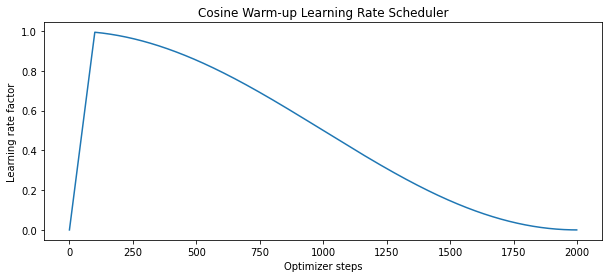

In [226]:
# Needed for initializing the lr scheduler
p = nn.Parameter(torch.empty(4,4))
optimizer = torch.optim.Adam([p], lr=1e-3)
lr_scheduler = CosineAnnealingWithWarmupLR(optimizer=optimizer, warmup_steps=100, max_steps=2000)

# Plotting
fig, ax = plt.subplots(figsize=(10, 4))
steps = range(2000)

ax.plot(steps, [lr_scheduler.get_lr_factor(e) for e in steps])
ax.set_ylabel("Learning rate factor")
ax.set_xlabel("Optimizer steps")
ax.set_title("Cosine Warm-up Learning Rate Scheduler");

**Задание 6 (0.1 балла):** обучите модель-классификатор палиндромов.

In [227]:
from util import train

Зададим параметры обучения и оптимизатора

In [228]:
num_epochs = 15
warmup_steps = 2000
lr = 5e-4

In [229]:
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.0)

scheduler = CosineAnnealingWithWarmupLR(
    optimizer,
    warmup_steps=warmup_steps,
    max_steps=int(num_epochs * len(train_loader))
)

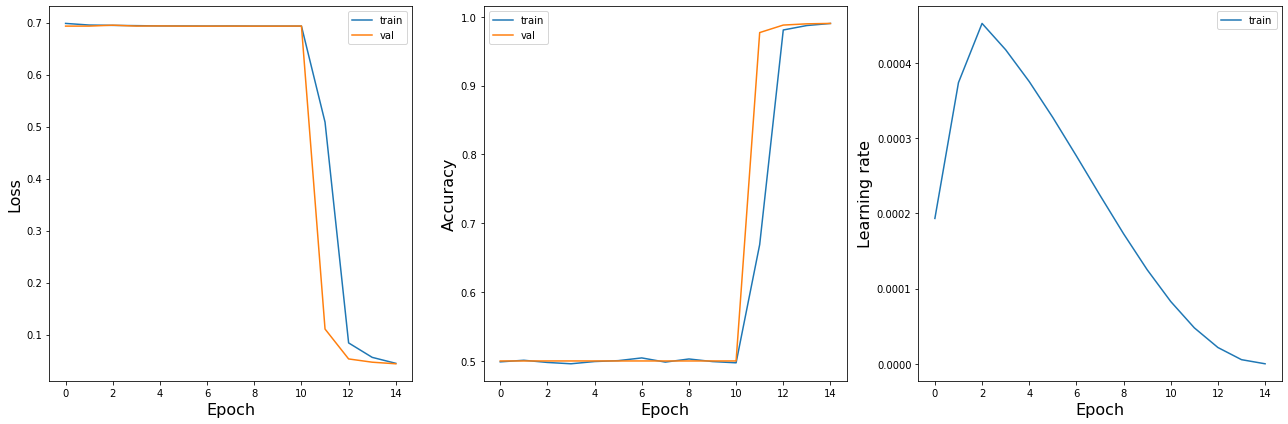

In [230]:
train(
    model,
    num_epochs=num_epochs,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device
)

In [231]:
torch.save(model, 'transformer')

Если все было реализовано верно, то модель должна выдавать качество > 95%

### Linformer
---

Механизм Attention очень мощный, но имеет существенный недостаток при работе с длинными последовательностями.

Как нетрудно заметить, операция $Q K^{T}$ квадратична по длине последовательности по сложности вычислений и занимаемой памяти.

Что может быть критично, если контекст важный для данного токена имеет длину более 1000 токенов. Было предложено множество подходов по замене или приближению операции  Attention на нечто имеющее субквадратичную сложность по длине последовательности. Для желающих узнать больше есть [хороший обзор по теме](https://lilianweng.github.io/posts/2020-04-07-the-transformer-family/), а в данной МДЗ будет предложено реализовать [Linformer](https://arxiv.org/abs/2006.04768).

Возьмем ранее обученную модель и ее матрицу `Attention`. Одной из основных характеристик матрицы является ее ранг и разложение по сингулярным числам. Если большая часть массы собственных/сингулярных значений концентрируется на первых нескольких собственных векторах, то эффективно матрица является отображением в пространство низкой размерности. 

Здесь можно вспомнить принцип работы `PCA`, где уменьшение размерности достигается за счет проекция на несколько первых сингулярных векторов. Построим нормализованную кумулятивную сумму первых $k$-собственных значений (известную в литературе как Explained Variance).

In [232]:
sequence, label = val_dataset[0]

In [233]:
with torch.no_grad():
    # we take attention only from the last layer
    attn = model.forward_attention(sequence[None, ...].to(device))[-1]

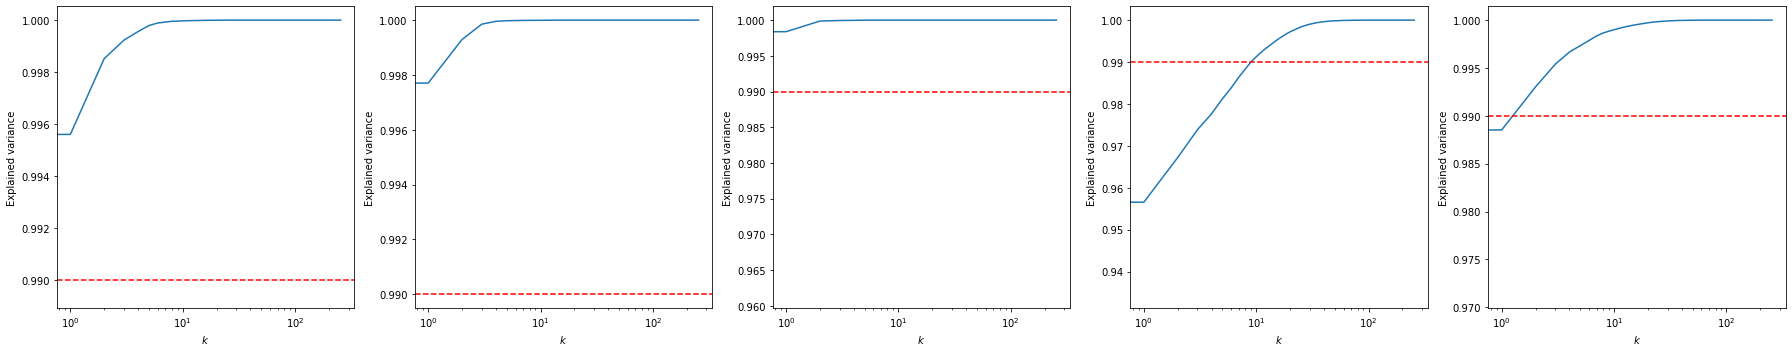

In [234]:
# select number such that num_heads divides it
heads_per_row = 5

fig, ax = plt.subplots(
    nrows=num_heads // heads_per_row,
    ncols=heads_per_row,
    figsize=(heads_per_row * 5, (num_heads // heads_per_row) * 5),
    squeeze=False
)

for head_idx in range(num_heads):
    row, col = head_idx // heads_per_row, head_idx % heads_per_row
    sing_vals = torch.linalg.svdvals(attn[0, head_idx, 1:, 1:]).cpu().numpy()
    expl_var  = np.cumsum(sing_vals ** 2, axis=0)
    expl_var /= expl_var[-1]
    ax[row, col].plot(expl_var)
    ax[row, col].axhline(0.99, linestyle='--', color='red')
    ax[row, col].set_xlabel(r'$k$')
    ax[row, col].set_ylabel(r'Explained variance')
    ax[row, col].set_xscale('log')

fig.tight_layout()

Что вы наблюдаете?

Отсюда и берет начало идея `Linformer`. 

Так как матрица Attention низкоранговая, вместо того чтобы считать большую квадратную матрицу $L \times L$, предлагается вычислять прямоугольную
$L \times k$, где $k \ll L$. 

Последовательности $K$ и $V$ (после прогонки через $W_K$, $W_V$) отображаются вдоль оси, отвечающей длине последовательности из $L$ - мерного пространства в $k$ - мерное. И только затем вычисляется скалярное произведение уже с $k$ ключами для всех query.

<p align="center">
  <img src="https://github.com/mryab/dl-hse-ami/blob/main/week08_transformers/LinformerAttention.png?raw=1" width="300" />
</p>

Вычислительная сложность уменьшается с $\mathcal{O}(L^2)$ до $\mathcal{O}(L k)$.

В конечном итоге операция `LinformerAttention` имеет следующий вид:

$$ \text{LinformerAttention}(Q,K,V)=\text{softmax}\left(\frac{Q (E K)^T}{\sqrt{d_k}}\right) F V $$ 

Выше $E$ и $F$ - обучаемые матрицы проекции.

<span style="color:red">Замечание</span>.

Описанный подход ограничивает применимость `Linformer` на последовательности фиксированной длины.

К счастью, в текущей задаче с такими мы и работаем.

**Задание 7 (0.2 балла):**. Реализуйте класс  `LinformerAttention` - реализующий операции описанные выше, и
`LinformerBlock`, `LinformerForSequenceClassification`, повторяющих функционал `EncoderBlock`, `TransformerForSequenceClassification`.

In [317]:
class LinformerAttention(nn.Module):

    def __init__(self, embed_dim, num_heads, sequence_length, proj_dim):
        """
        Args:
            embed_dim: dimensionality of embedding (total)
            num_heads: number of heads (must divide embed_dim)
            sequence_length: length of the input sequence
            proj_dim: length of  the projected sequence
        """
        super().__init__()
        assert embed_dim % num_heads == 0, "Embedding dimension must be 0 modulo number of heads."


        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.q_proj = nn.Linear(self.embed_dim, self.embed_dim)
        self.k_proj = nn.Linear(self.embed_dim, self.embed_dim)
        self.v_proj = nn.Linear(self.embed_dim, self.embed_dim)
        self.o_proj = nn.Linear(self.embed_dim, self.embed_dim)
        # projections on sequence length
        self.e_proj = nn.Linear(sequence_length, proj_dim)
        self.f_proj = nn.Linear(sequence_length, proj_dim)

        self._reset_parameters()

    def _reset_parameters(self):
        for layer in self.modules():
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                if layer.bias is not None:
                    layer.bias.data.fill_(0)

    def forward(self, x, return_attention=False):
        """
        Args:
            x: torch.Tensor (B, L, D)
            return_attention: If specified, returns attention along with outputs
        Returns:
            outputs: torch.Tensor (B, L, D)
            attention: Optional[torch.Tensor] (B, num_heads, L, L)

        B is batch size, L is the length of sequence, D is the embedding dimension
        """
        fv = self.f_proj(self.v_proj(x).transpose(-1, -2)).transpose(-1, -2)
        ek = self.e_proj(self.k_proj(x).transpose(-1, -2)).transpose(-1, -2)

        value = torch.stack(torch.split(fv, self.head_dim, dim=-1), dim=0).transpose(0, 1)
        key = torch.stack(torch.split(ek, self.head_dim, dim=-1), dim=0).transpose(0, 1)
        query = torch.stack(torch.split(self.q_proj(x), self.head_dim, dim=-1), dim=0).transpose(0, 1)

        out, attention = scaled_softmax_attention(query, key, value)

        outputs = self.o_proj(out.transpose(1, 2).reshape(x.shape))
        if return_attention:
            return outputs, attention
        else:
            return outputs


class LinformerBlock(EncoderBlock):

    def __init__(self, embed_dim, num_heads, feedforward_dim, sequence_length, proj_dim, activation=nn.ReLU, dropout=0.0):
        """
        Inputs:
            embed_dim - Dimensionality of the input
            num_heads - Number of heads to use in the attention block
            feedforward_dim - Dimensionality of the hidden layer in the MLP
            activation - activation function in FFN
            sequence_length: length of the input sequence
            proj_dim: length of  the projected sequence
            dropout - Dropout probability to use in the dropout layers
        """
        super(EncoderBlock, self).__init__()
        
        self.mha = LinformerAttention(embed_dim, num_heads, sequence_length, proj_dim)
        self.DP = nn.Dropout(dropout)
        self.LN_one = nn.LayerNorm(embed_dim)
        self.lin = nn.Sequential(
            nn.Linear(embed_dim, feedforward_dim),
            activation(),
            nn.Linear(feedforward_dim, embed_dim),
            activation(),
            nn.Dropout(dropout)
        )
        self.LN_two = nn.LayerNorm(embed_dim)



class LinformerForSequenceClassification(TransformerForSequenceClassification):

    def __init__(
        self,
        input_dim: int,
        embed_dim: int,
        num_classes: int,
        num_heads: int,
        feedforward_dim: int,
        num_layers: int,
        sequence_length: int,
        proj_dim: int,
        activation = nn.GELU,
        max_len: int = 5000,
        dropout: float = 0.0
    ):
        super(TransformerForSequenceClassification, self).__init__()
        
        self.cls_token =  torch.rand((embed_dim,)).to(device) 
        self.input_embedding = nn.Linear(input_dim, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim, max_len)

        encoder_blocks = [LinformerBlock(embed_dim, num_heads, feedforward_dim, 
                                         sequence_length, proj_dim, activation, dropout) 
                          for _ in range(num_layers)]
        self.encoder = nn.Sequential(*encoder_blocks)

        self.classifier = nn.Linear(embed_dim, num_classes)

Сравним зависимость расхода памяти от длины последовательности
для `Transformer` и `Linformer`.

In [318]:
embed_dim = 8
sequence_lengths = [64, 128, 256, 512, 1024, 2048, 4096]

mem_usages = {'transformer': [], 'linformer': []}

for sequence_length in sequence_lengths:
    # generate input
    input = torch.randn(32, sequence_length, embed_dim, device=device)
    # define transformer block
    transformer_attn = MultiheadAttention(
        embed_dim=embed_dim,
        num_heads=1
    ).to(device)
    # define linformer block
    linformer_attn = LinformerAttention(
        embed_dim=embed_dim,
        num_heads=1,
        sequence_length=sequence_length,
        proj_dim=8
    ).to(device)

    # get memory usage for model
    for model_name, attn_layer in zip(
        ['transformer', 'linformer'],
        [transformer_attn, linformer_attn]
    ):
        mem_alloc_pre = torch.cuda.memory_allocated()
        output = attn_layer(input)
        mem_alloc_aft = torch.cuda.memory_allocated()
        # convert to Mb
        mem_usages[model_name].append((mem_alloc_aft - mem_alloc_pre) / 2 ** 20)
        # free output
        del output
        torch.cuda.empty_cache()

    # free memory
    del input, transformer_attn, linformer_attn
    torch.cuda.empty_cache()

Построим графики

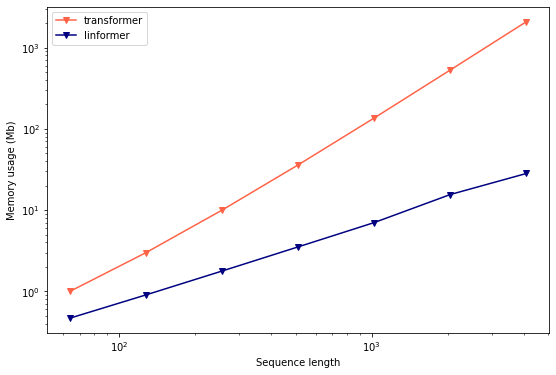

In [316]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(sequence_lengths, mem_usages['transformer'], '-v',
        color='tomato', label='transformer')
ax.plot(sequence_lengths, mem_usages['linformer'], '-v',
        color='navy', label='linformer')
# define x,y label
ax.set_xlabel('Sequence length')
ax.set_ylabel('Memory usage (Mb)')
# plot in logspace
ax.set_xscale('log');
ax.set_yscale('log');
# plot legend
ax.legend();

Как видно, используемая Трансформером память растет значительно быстрее с ростом длины последовательности.

**Задание 8 (0.1 балла):** обучите `Linformer` на том же самом датасете.

In [319]:
# model hyperparams
embed_dim = 300
num_heads = 5
feedforward_dim = 300
num_layers = 1
proj_dim = 64
# the same as for transformer task
sequence_length = 256

In [320]:
model = LinformerForSequenceClassification(
    num_classes=1,
    input_dim=vocab_length,
    embed_dim=embed_dim,
    num_heads=num_heads,
    feedforward_dim=feedforward_dim,
    sequence_length=(sequence_length + 1),
    proj_dim=proj_dim,
    activation=nn.ReLU,
    num_layers=num_layers,
)
# put model on device
model = model.to(device)

In [321]:
num_epochs = 20
warmup_steps = 2000
lr = 5e-5

In [322]:
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.0)

In [323]:
scheduler = CosineAnnealingWithWarmupLR(
    optimizer,
    warmup_steps=warmup_steps,
    max_steps=int(num_epochs * len(train_loader))
)

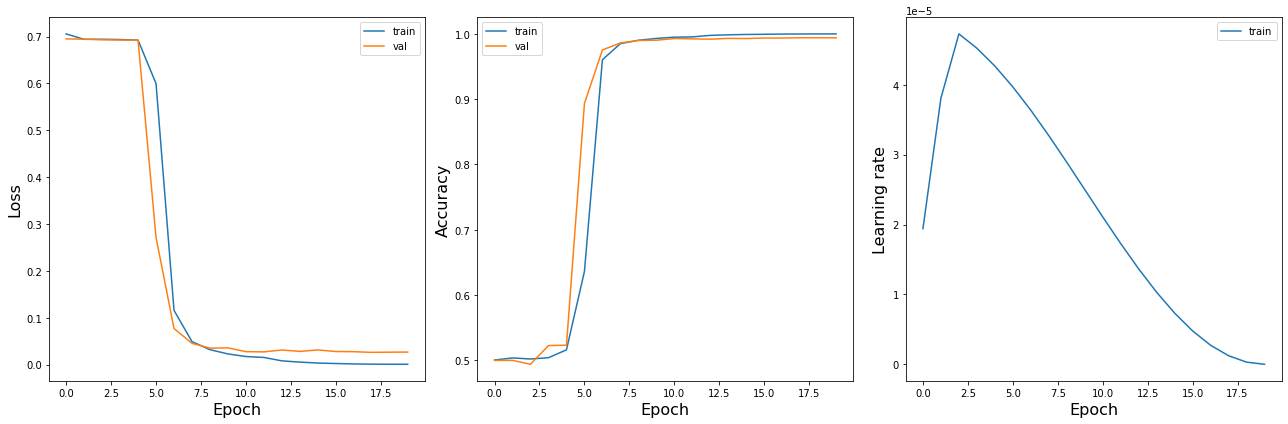

In [324]:
train(
    model,
    num_epochs=num_epochs,
    optimizer=optimizer,
    scheduler=scheduler,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device
)

Если все было реализовано правильно, `Linformer` должен так же успешно справляться с задачей определения палиндрома.